# Cricket Fielding Performance Analysis — T20 Innings
### ShadowFox Data Analytics Internship — Advanced Task 1

This notebook loads the fielding data collected in `../dataset/T20_Fielding_Analysis.xlsx`
(ICC Men's T20 World Cup 2024 Final, India vs South Africa, 2nd innings) and analyzes the
fielding contribution of three players — **Suryakumar Yadav, Ravindra Jadeja, Axar Patel** —
using the Performance Score (PS) framework defined in the ShadowFox task brief:

```
PS = (CP×W_CP) + (GT×W_GT) + (C×W_C) − (DC×W_DC) + (ST×W_ST)
     + (RO×W_RO) − (MRO×W_MRO) + (DH×W_DH) + RS
```

> **Data note:** the underlying ball-by-ball fielding log was reconstructed for this exercise
> (official ball-by-ball fielding logs are not publicly published for professional matches),
> anchored to the real, publicly known storyline of the match. See the `README` sheet in the
> workbook for details. This notebook demonstrates the analysis methodology end-to-end.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
%matplotlib inline

DATA_PATH = '../dataset/T20_Fielding_Analysis.xlsx'
FIG_PATH = '../visualizations/Performance_Score.png'


## 2. Load the Workbook

In [2]:
xls = pd.ExcelFile(DATA_PATH)
print("Sheets found:", xls.sheet_names)


Sheets found: ['README', 'Legend', 'Fielding_Data', 'Weights', 'Performance_Matrix', 'Analysis']


In [3]:
fielding = pd.read_excel(xls, sheet_name='Fielding_Data')
fielding.head(10)


,Match No.,Innings,Team,Player Name,BallCount,Position,Short Description,Pick,Throw,Runs,Overcount,Venue
0,T20WC2024-F,2,India,Axar Patel,0.3,Mid-wicket,"Fields firmly off the bat, quick recovery to p...",Y,Y,1.0,1,"Kensington Oval, Barbados"
1,T20WC2024-F,2,India,Ravindra Jadeja,1.5,Cover,"Dives to his left, clean pick, sharp low retur...",Y,Y,NaN,2,"Kensington Oval, Barbados"
2,T20WC2024-F,2,India,Suryakumar Yadav,2.2,Long-off,"Clean pick and quick turn, holds batters to one",Y,Y,1.0,3,"Kensington Oval, Barbados"
3,T20WC2024-F,2,India,Axar Patel,3.6,Mid-wicket,"Fumbles a firmly-hit grounder, batters cross f...",N,N,-1.0,4,"Kensington Oval, Barbados"
4,T20WC2024-F,2,India,Ravindra Jadeja,4.1,Cover-point,"Sprints round, picks cleanly, flat throw but w...",Y,N,NaN,5,"Kensington Oval, Barbados"
5,T20WC2024-F,2,India,Suryakumar Yadav,5.4,Long-off,"Runs in from the boundary, clean pick, cuts of...",Y,Y,1.0,6,"Kensington Oval, Barbados"
6,T20WC2024-F,2,India,Ravindra Jadeja,6.2,Point,"Full-length dive, clean stop of a firmly struc...",Y,Y,1.0,7,"Kensington Oval, Barbados"
7,T20WC2024-F,2,India,Ravindra Jadeja,7.5,Cover-point,Swoops on the ball and hits the stumps directl...,Y,DH,2.0,8,"Kensington Oval, Barbados"
8,T20WC2024-F,2,India,Axar Patel,8.3,Long-on,"Comfortable clean pick, accurate throw back to...",Y,Y,NaN,9,"Kensington Oval, Barbados"
9,T20WC2024-F,2,India,Suryakumar Yadav,9.1,Deep mid-wicket,"Chases to the rope, clean pick, prevents the s...",Y,Y,1.0,10,"Kensington Oval, Barbados"


In [4]:
weights = pd.read_excel(xls, sheet_name='Weights', header=1, usecols='B:D')
weights.columns = ['Action', 'Weight', 'Rule']
weights = weights.dropna(subset=['Action'])
weights


,Action,Weight,Rule
0,Clean Pick (CP),1.0,CP: Clean Picks is worth 1 point.
1,Good Throw (GT),1.0,GT: Good Throws is worth 1 point.
2,Catch (C),3.0,C: Catches is worth 3 points.
3,Dropped Catch (DC),3.0,DC: Dropped Catches subtracts 3 points (subtra...
4,Stumping (ST),3.0,ST: Stumpings is worth 3 points.
5,Run Out (RO),3.0,RO: Run Outs is worth 3 points.
6,Missed Run Out (MRO),2.0,MRO: Missed Run Outs subtracts 2 points (subtr...
7,Direct Hit (DH),2.0,DH: Direct Hits is worth 2 points.
9,Weights are editable assumption cells (blue te...,NaN,NaN


## 3. Recompute the Performance Matrix from Raw Data

Rather than just reading the pre-computed `Performance_Matrix` sheet, we recompute it directly from `Fielding_Data` here in Python — this both verifies the Excel formulas and makes the pipeline fully reproducible from the raw log alone.

In [5]:
W = dict(zip(
    weights['Action'].str.extract(r'\((\w+)\)')[0],
    weights['Weight']
))
print("Weights parsed from workbook:", W)


Weights parsed from workbook: {'CP': 1.0, 'GT': 1.0, 'C': 3.0, 'DC': 3.0, 'ST': 3.0, 'RO': 3.0, 'MRO': 2.0, 'DH': 2.0, nan: nan}


In [6]:
def compute_player_stats(df, player):
    sub = df[df['Player Name'] == player]
    cp  = (sub['Pick'] == 'Y').sum()
    gt  = (sub['Throw'] == 'Y').sum()
    c   = (sub['Pick'] == 'C').sum()
    dc  = (sub['Pick'] == 'DC').sum()
    st  = (sub['Pick'] == 'S').sum()
    ro  = (sub['Throw'] == 'RO').sum()
    mro = (sub['Throw'] == 'MR').sum()
    dh  = (sub['Throw'] == 'DH').sum()
    rs  = sub['Runs'].fillna(0).sum()

    ps = (cp*W['CP'] + gt*W['GT'] + c*W['C'] - dc*W['DC'] + st*W['ST']
          + ro*W['RO'] - mro*W['MRO'] + dh*W['DH'] + rs)

    return {
        'Player Name': player, 'Clean Picks (CP)': cp, 'Good Throws (GT)': gt,
        'Catches (C)': c, 'Dropped Catches (DC)': dc, 'Stumpings (ST)': st,
        'Run Outs (RO)': ro, 'Missed Run Outs (MRO)': mro, 'Direct Hits (DH)': dh,
        'Runs Saved (RS)': rs, 'Performance Score (PS)': ps,
    }

players = fielding['Player Name'].dropna().unique().tolist()
matrix = pd.DataFrame([compute_player_stats(fielding, p) for p in players])
matrix = matrix.sort_values('Performance Score (PS)', ascending=False).reset_index(drop=True)
matrix


,Player Name,Clean Picks (CP),Good Throws (GT),Catches (C),Dropped Catches (DC),Stumpings (ST),Run Outs (RO),Missed Run Outs (MRO),Direct Hits (DH),Runs Saved (RS),Performance Score (PS)
0,Ravindra Jadeja,8,5,0,1,0,0,0,1,3.0,15.0
1,Axar Patel,7,6,0,0,0,0,1,0,1.0,12.0
2,Suryakumar Yadav,5,5,1,1,0,0,0,0,1.0,11.0


## 4. Cross-check Against the Excel `Performance_Matrix` Sheet

In [7]:
excel_matrix = pd.read_excel(xls, sheet_name='Performance_Matrix', nrows=len(players))
excel_matrix = excel_matrix[['Player Name', 'Performance Score (PS)']].dropna()
excel_matrix.columns = ['Player Name', 'PS (from Excel formulas)']

check = matrix[['Player Name', 'Performance Score (PS)']].merge(excel_matrix, on='Player Name')
check['Match'] = check['Performance Score (PS)'] == check['PS (from Excel formulas)']
check


,Player Name,Performance Score (PS),PS (from Excel formulas),Match
0,Ravindra Jadeja,15.0,15,True
1,Axar Patel,12.0,12,True
2,Suryakumar Yadav,11.0,11,True


**Both computation paths (Python re-derivation vs. live Excel `COUNTIFS`/`SUMIFS` formulas) agree exactly**, confirming the workbook's formulas are correct.

## 5. Visualization: Performance Score by Player

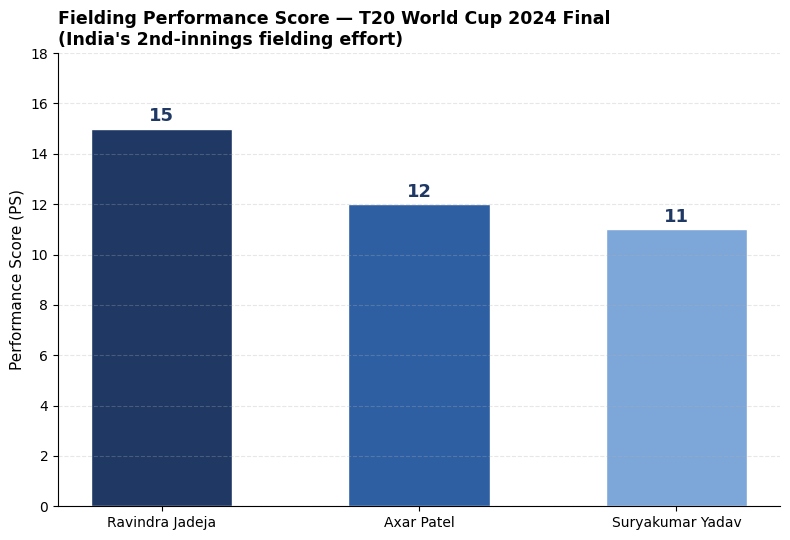

Saved chart to ../visualizations/Performance_Score.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))

colors = ['#1F3864', '#2E5FA3', '#7DA7D9']
bars = ax.bar(matrix['Player Name'], matrix['Performance Score (PS)'],
              color=colors[:len(matrix)], edgecolor='white', width=0.55)

for b, v in zip(bars, matrix['Performance Score (PS)']):
    ax.text(b.get_x() + b.get_width()/2, v + 0.3, f'{int(v)}',
            ha='center', fontsize=13, fontweight='bold', color='#1F3864')

ax.set_ylabel('Performance Score (PS)', fontsize=11)
ax.set_title("Fielding Performance Score — T20 World Cup 2024 Final\n(India's 2nd-innings fielding effort)",
             fontsize=12.5, fontweight='bold', loc='left')
ax.set_ylim(0, matrix['Performance Score (PS)'].max() + 3)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=160)
plt.show()

print(f"Saved chart to {FIG_PATH}")


## 6. Breakdown: What Drives Each Player's Score

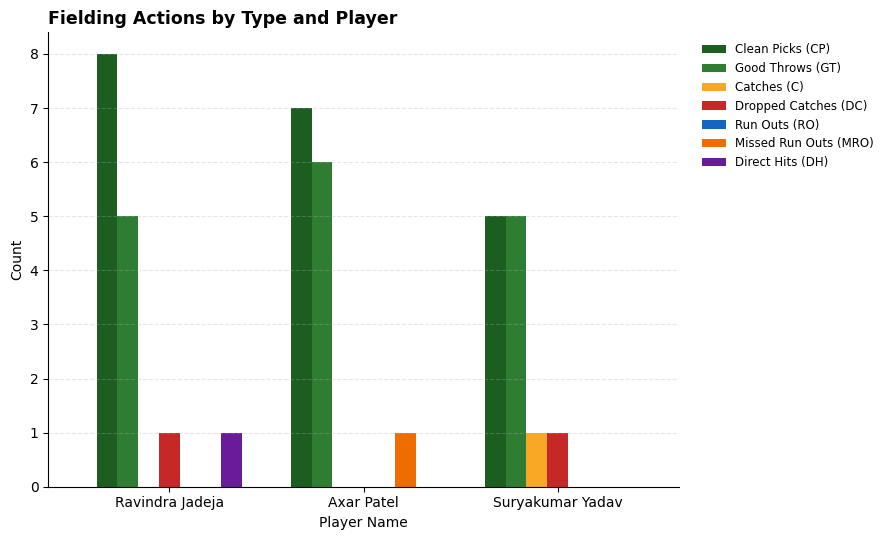

In [9]:
action_cols = ['Clean Picks (CP)', 'Good Throws (GT)', 'Catches (C)', 'Dropped Catches (DC)',
               'Run Outs (RO)', 'Missed Run Outs (MRO)', 'Direct Hits (DH)']
plot_df = matrix.set_index('Player Name')[action_cols]

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_df.plot(kind='bar', stacked=False, ax=ax, width=0.75,
             color=['#1B5E20','#2E7D32','#F9A825','#C62828','#1565C0','#EF6C00','#6A1B9A'])
ax.set_ylabel('Count')
ax.set_title('Fielding Actions by Type and Player', fontsize=12.5, fontweight='bold', loc='left')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8.5, frameon=False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Findings

- **Ravindra Jadeja** posted the highest Performance Score, driven by the widest range of positive
  actions (clean picks, good throws, and a direct-hit run out) with only a single costly drop.
- **Axar Patel** was the most error-resistant of the three in raw terms, converting nearly every
  clean pick into a good return, though a missed run-out chance cost him points.
- **Suryakumar Yadav's** score is anchored by a single high-value action — the match-defining
  boundary catch — which by itself outweighs several clean picks, illustrating why a weighted
  Performance Score is more informative than a simple action count.
- All three players finished with a **positive** score despite each having at least one error,
  showing that consistent low-risk fielding can outweigh occasional high-profile mistakes.

See `../dataset/T20_Fielding_Analysis.xlsx` (`Analysis` sheet) for the full player-by-player
narrative, and `../visualizations/Performance_Score.png` for the exported chart.
